In [305]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
# %matplotlib inline

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 8)

RNG = np.random.default_rng(42)

In [22]:
# Based on https://janakiev.com/blog/covariance-matrix/

# Correlate & Decorrelate

## Generate data

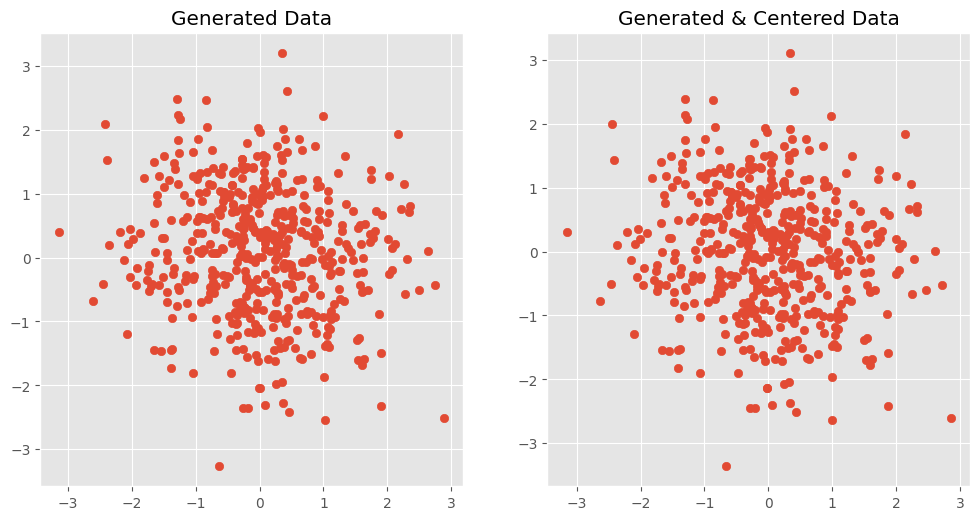

In [95]:
X_origin = RNG.normal(0, 1, (500, 2))
# X_origin = RNG.exponential(1, (500, 2))
# X_origin = RNG.gamma(1, 1, (500, 2))
# X_origin = RNG.beta(0.5, 0.5, (500, 2))

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.scatter(X_origin[:, 0], X_origin[:, 1])
ax1.set_title('Generated Data')
ax1.set_aspect('equal');# Center the matrix at the origin

X_origin = X_origin - np.mean(X_origin, 0)

ax2.scatter(X_origin[:, 0], X_origin[:, 1])
ax2.set_title('Generated & Centered Data')
ax2.set_aspect('equal');

## cov_mat

In [24]:
# Covariance
def cov(x, y):
    xbar, ybar = x.mean(), y.mean()
    return np.sum((x - xbar)*(y - ybar))/(len(x) - 1)

# Covariance matrix
def cov_mat(X):
    return np.array([[cov(X[0], X[0]), cov(X[0], X[1])], [cov(X[1], X[0]), cov(X[1], X[1])]])
    
# Calculate covariance matrix
# Must yield near Identity matrix since we samples from Normal without correlation among dimensions
c1 = cov_mat(X_origin.T) # (or with np.cov(X.T))
c2 = (X_origin.T @ X_origin) / (len(X_origin) - 1)
np.round(c1, 2), np.round(c2, 2)

(array([[0.98, 0.15],
        [0.15, 0.98]]),
 array([[0.98, 0.15],
        [0.15, 0.98]]))

## Scale

(array([[ 0.48,  0.35],
        [ 0.35, 11.28]]),
 array([[ 0.48,  0.35],
        [ 0.35, 11.28]]))

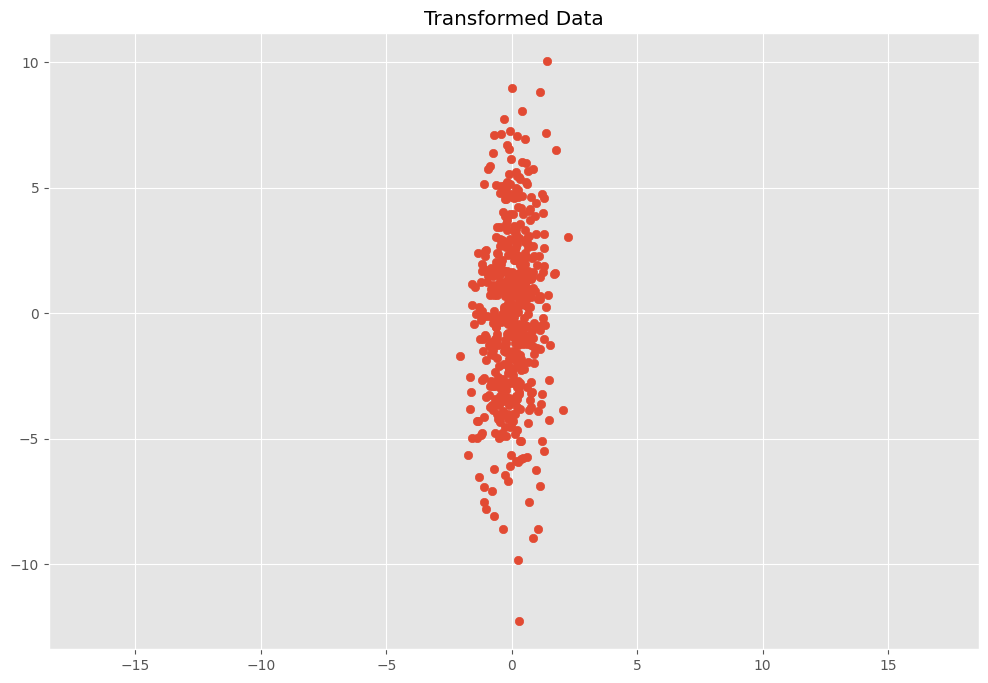

In [25]:
# Scaling matrix
sx, sy = 0.7, 3.4
scale_mat = np.array([[sx, 0], [0, sy]])

# Apply scaling matrix to X
X_transf = (scale_mat @ X_origin.T).T

plt.scatter(X_transf[:, 0], X_transf[:, 1])
plt.title('Transformed Data')
plt.axis('equal')

# Calculate covariance matrix
c1 = cov_mat(X_transf.T)
c2 = (X_transf.T @ X_transf) / (len(X_transf) - 1)
np.round(c1, 2), np.round(c2, 2)

## Scale + rotate

In [127]:
np.sqrt(rot_mat @ scale_mat @ scale_mat @ rot_mat.T)

array([[0.79056942, 0.61237244],
       [0.61237244, 0.79056942]])

In [133]:
np.sqrt((np.cos(theta)*sx)**2 + (np.sin(theta)*1)**2)

np.float64(1.0)

In [122]:
rot_mat

array([[ 0.70710678, -0.70710678],
       [ 0.70710678,  0.70710678]])

(array([[0.7 , 0.39],
        [0.39, 0.58]]),
 array([[0.7 , 0.39],
        [0.39, 0.58]]),
 array([[0.7 , 0.39],
        [0.39, 0.58]]),
 array([[0.7 , 0.39],
        [0.39, 0.58]]),
 array([[0.7 , 0.39],
        [0.39, 0.58]]),
 array([[0.63, 0.38],
        [0.38, 0.62]]),
 array([[0.63, 0.38],
        [0.38, 0.62]]))

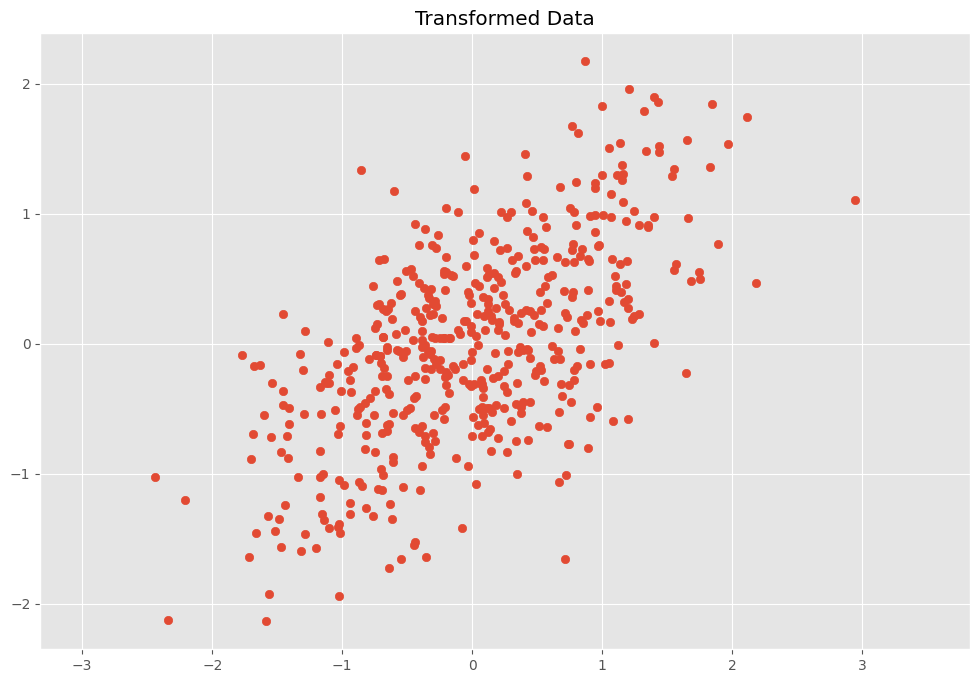

In [126]:
# Scaling matrix
sx, sy = 1, 0.5
# sx, sy = 1, 20
# sx, sy = np.sqrt(360), 1
scale_mat = np.array([[sx, 0], [0, sy]])

# Rotation matrix
# theta = np.deg2rad(3)
theta = np.deg2rad(45)
c, s = np.cos(theta), np.sin(theta)
rot_mat = np.array([[c, -s], [s, c]])

# Transformation matrix
T = rot_mat @ scale_mat # сначала scale_mat потом rot_mat, T = RS

# Apply transformation matrix to X
# X_transf = (rot_mat @ scale_mat @ X_origin.T).T # X_transf = RS(X_Origin)
X_transf = (T @ X_origin.T).T # X_transf = RS(X_Origin)

X_line_pts_count = 100
X_line = np.vstack([np.linspace(-10, 10, X_line_pts_count), np.zeros(X_line_pts_count)]).T
X_line_transf = (rot_mat @ X_line.T).T # X_transf = RS(X_line)

plt.scatter(X_transf[:, 0], X_transf[:, 1])
# plt.scatter(X_line_transf[:, 0], X_line_transf[:, 1], marker='.')
plt.title('Transformed Data')
plt.axis('equal');
# plt.xlim(-1, +1)
# plt.ylim(-1, +1)

# Calculate covariance
c1 = cov_mat(X_transf.T)
c2 = (X_transf.T @ X_transf) / (len(X_transf) - 1)
R = rot_mat
S = scale_mat
c3 = ((R @ S @ X_origin.T) @ (R @ S @ X_origin.T).T) / (len(X_transf) - 1)
c4 = (R @ S @ X_origin.T @ (X_origin.T).T @ S.T @ R.T) / (len(X_transf) - 1)
c5 = (R @ S @ X_origin.T @ X_origin @ S.T @ R.T) / (len(X_transf) - 1)
# Meantime (X_origin.T @ X_origin) / (len(X_transf) - 1) is close to I, because X_origin is drawn from N(0, 1), as such
c6 = (R @ S @ S.T @ R.T) # => cov = T(T.T)
c7 = (R @ S @ S @ R.T) # => since scale_mat is symmetric
# c6 and c7 must converge to c1 when len(X_origin) -> inf. But given only several hunders of samples c6 and c7 are expected to differ from c1 to some extent
np.round(c1, 2), np.round(c2, 2), np.round(c3, 2), np.round(c4, 2), np.round(c5, 2), np.round(c6, 2), np.round(c7, 2)

## Scale + shear + rotate

(array([[ 0.37, -0.31],
        [-0.31, 14.55]]),
 array([[ 0.37, -0.31],
        [-0.31, 14.55]]),
 array([[ 0.37, -0.31],
        [-0.31, 14.55]]),
 array([[ 0.37, -0.31],
        [-0.31, 14.55]]),
 array([[ 0.37, -0.31],
        [-0.31, 14.55]]),
 array([[ 0.69, -5.09],
        [-0.5 , 11.96]]),
 array([[ 0.69, -5.09],
        [-0.5 , 11.96]]))

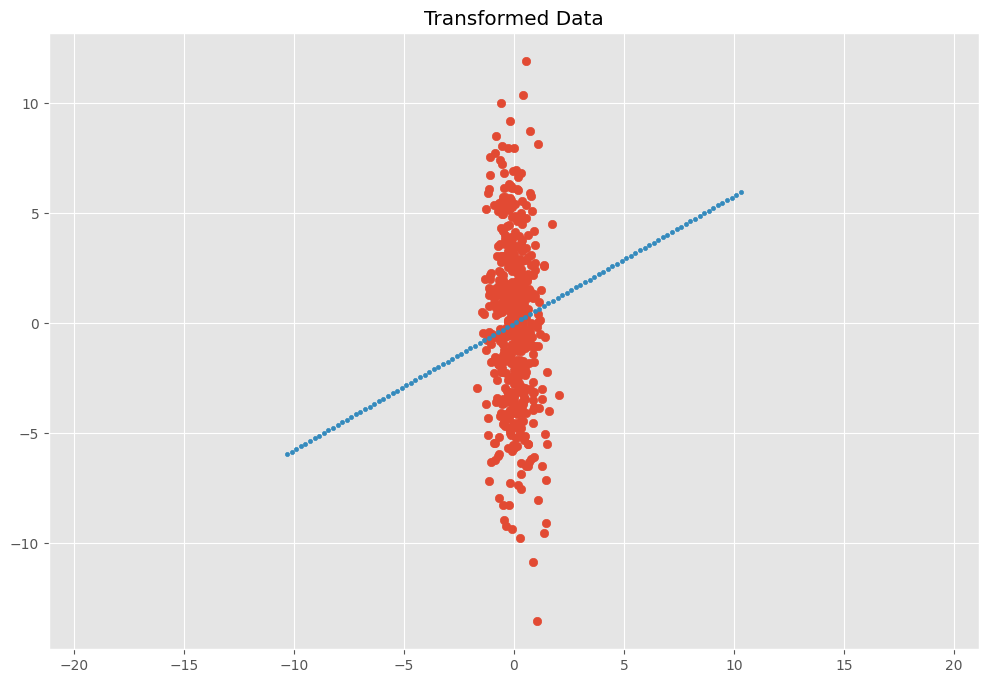

In [27]:
# Scaling matrix
sx, sy = 0.7, 3.4
scale_mat = np.array([[sx, 0], [0, sy]])

# Shear matrix
shear_mat = np.array([[1, 0.5], [0, 1]])

# Rotation matrix
theta = np.deg2rad(30)
c, s = np.cos(theta), np.sin(theta)
rot_mat = np.array([[c, -s], [s, c]])

# Transformation matrix
T = rot_mat @ shear_mat @ scale_mat # сначала scale_mat потом shear_mat потом rot_mat, T = RHS

# Apply transformation matrix to X
# X_transf = (rot_mat @ shear_mat @ scale_mat @ X_origin.T).T # X_transf = RS(X_Origin)
X_transf = (T @ X_origin.T).T # X_transf = RS(X_Origin)

max_value = np.abs(np.max(X_transf))
X_line_pts_count = 100
X_line = np.vstack([np.linspace(-max_value, max_value, X_line_pts_count), np.zeros(X_line_pts_count)]).T
X_line_transf = (rot_mat @ X_line.T).T # X_transf = RS(X_line)

plt.scatter(X_transf[:, 0], X_transf[:, 1])
plt.scatter(X_line_transf[:, 0], X_line_transf[:, 1], marker='.')
plt.title('Transformed Data')
plt.axis('equal');

# Calculate covariance
c1 = cov_mat(X_transf.T)
c2 = (X_transf.T @ X_transf) / (len(X_transf) - 1)
R = rot_mat
S = scale_mat
H = shear_mat
c3 = ((R @ H @ S @ X_origin.T) @ (R @ H @ S @ X_origin.T).T) / (len(X_transf) - 1)
c4 = (R @ H @ S @ X_origin.T @ (X_origin.T).T @ S.T @ H.T @ R.T) / (len(X_transf) - 1)
c5 = (R @ H @ S @ X_origin.T @ X_origin @ S.T @ H.T @ R.T) / (len(X_transf) - 1)
# Meantime (X_origin.T @ X_origin) / (len(X_transf) - 1) is close to I, because X_origin is drawn from N(0, 1), as such
c6 = (R @ S @ H @ S.T @ H.T @ R.T) # => cov = T(T.T)
c7 = (R @ S @ H @ S @ H.T @ R.T) # => since scale_mat is symmetric
# c6 and c7 must converge to c1 when len(X_origin) -> inf. But given only several hunders of samples c6 and c7 are expected to differ from c1 to some extent
np.round(c1, 2), np.round(c2, 2), np.round(c3, 2), np.round(c4, 2), np.round(c5, 2), np.round(c6, 2), np.round(c7, 2)

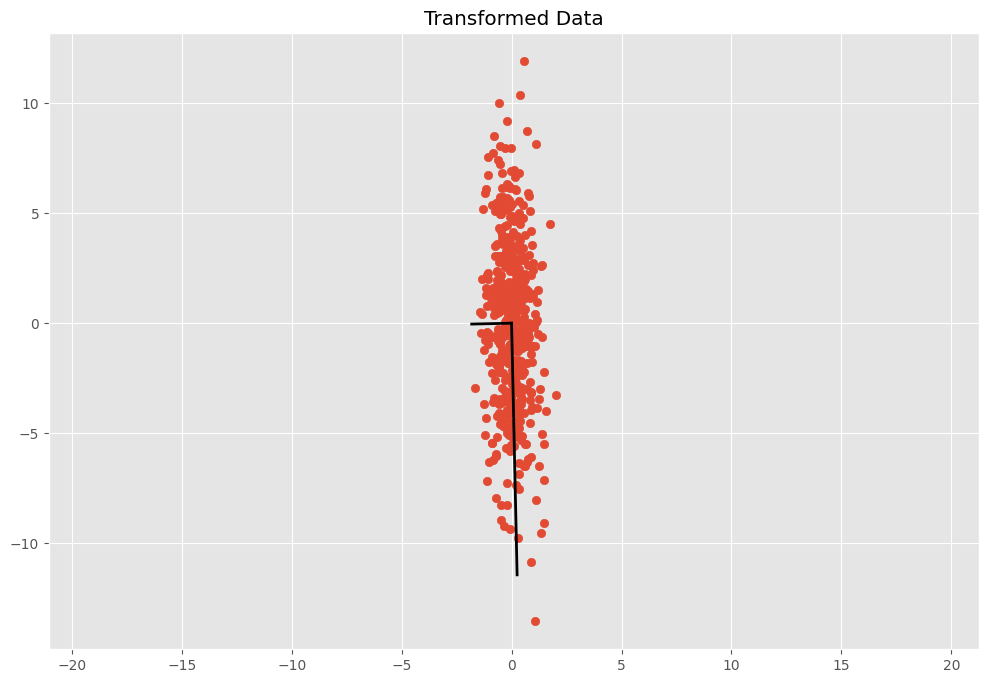

In [28]:
C = cov_mat(X_transf.T)
eVa, eVe = np.linalg.eig(C)

plt.scatter(X_transf[:, 0], X_transf[:, 1])

for val, vec in zip(eVa, eVe.T):
    plt.plot([0, 3*np.sqrt(val)*vec[0]], [0, 3*np.sqrt(val)*vec[1]], 'k-', lw=2)
    
plt.title('Transformed Data')
plt.axis('equal');

## Restore directly

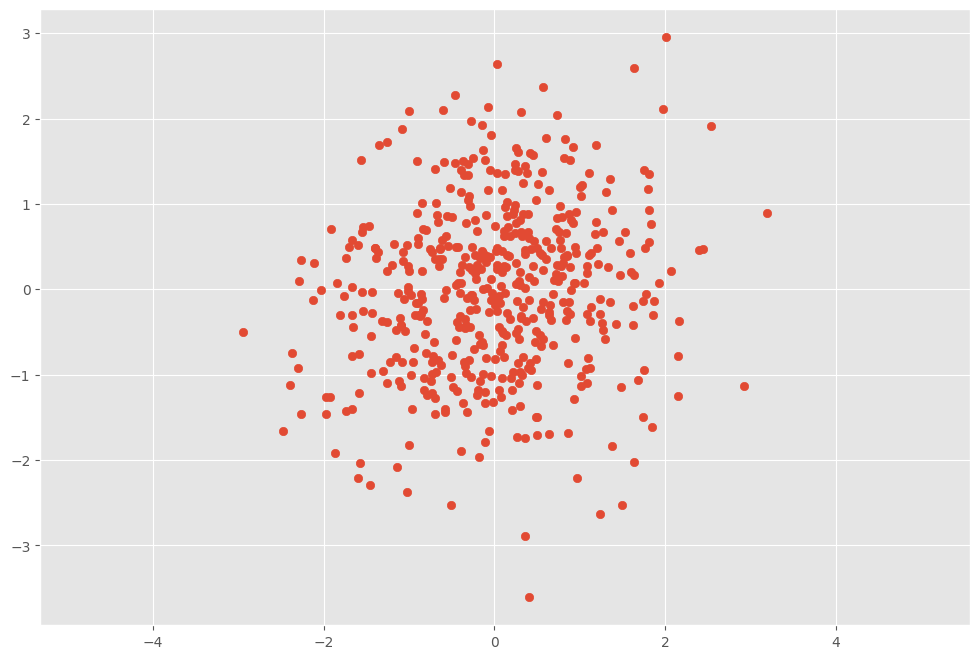

In [29]:
# All below must yield the same result

# 1)
# qqq = (np.linalg.inv(scale_mat) @ np.linalg.inv(shear_mat) @ np.linalg.inv(rot_mat) @ rot_mat @ shear_mat @ scale_mat @ X_origin.T).T

# 2)
# qqq = (np.linalg.inv(scale_mat) @ np.linalg.inv(shear_mat) @ np.linalg.inv(rot_mat) @ X_transf.T).T

# 3)
# scale_mat_inv = np.reciprocal(scale_mat, out=np.zeros_like(scale_mat), where=(scale_mat != 0))
# qqq = (scale_mat_inv @ np.linalg.inv(shear_mat) @ np.linalg.inv(rot_mat) @ X_transf.T).T

# 4)
scale_mat_inv = np.reciprocal(scale_mat, out=np.zeros_like(scale_mat), where=(scale_mat != 0))
rot_mat_inv = rot_mat.T
qqq = (scale_mat_inv @ np.linalg.inv(shear_mat) @ rot_mat_inv @ X_transf.T).T

plt.scatter(qqq[:,0], qqq[:,1])
plt.axis('equal');

## Restore via eigendecomposition 1

array([[1.00000000e+00, 2.13590001e-17],
       [2.13590001e-17, 1.00000000e+00]])

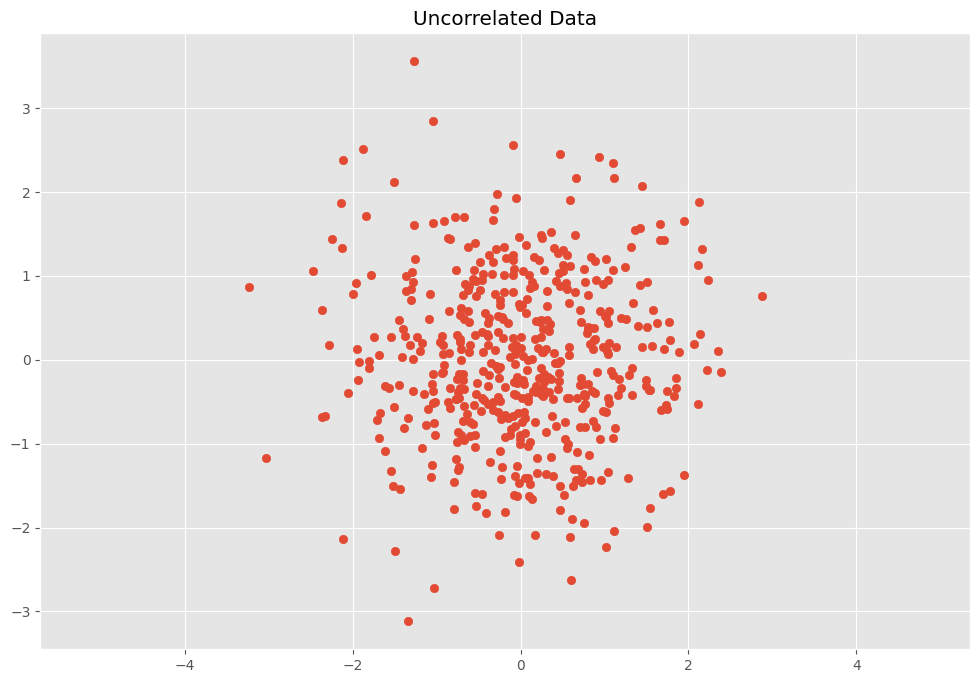

In [30]:
C = cov_mat(X_transf.T)

eVa, eVe = np.linalg.eig(C)

# Calculate transformation matrix from eigen decomposition
R, S = eVe, np.diag(np.sqrt(eVa))
# Здесь легко может быть ситуация, что R = -rot_mat, т.к. с т.з. eigendecomposition нет разницы между поворотом на 30 или на 210 (30+180)
T = R @ S
T_inv = np.linalg.inv(T)

# Transform data with inverse transformation matrix T^-1
X_restored = (T_inv @ X_transf.T).T

plt.scatter(X_restored[:, 0], X_restored[:, 1])
plt.title('Uncorrelated Data')
plt.axis('equal');

# Covariance matrix of the uncorrelated data
cov_mat(X_restored.T)

## Restore via eigendecomposition 2

array([[1.00000000e+00, 2.13590001e-17],
       [2.13590001e-17, 1.00000000e+00]])

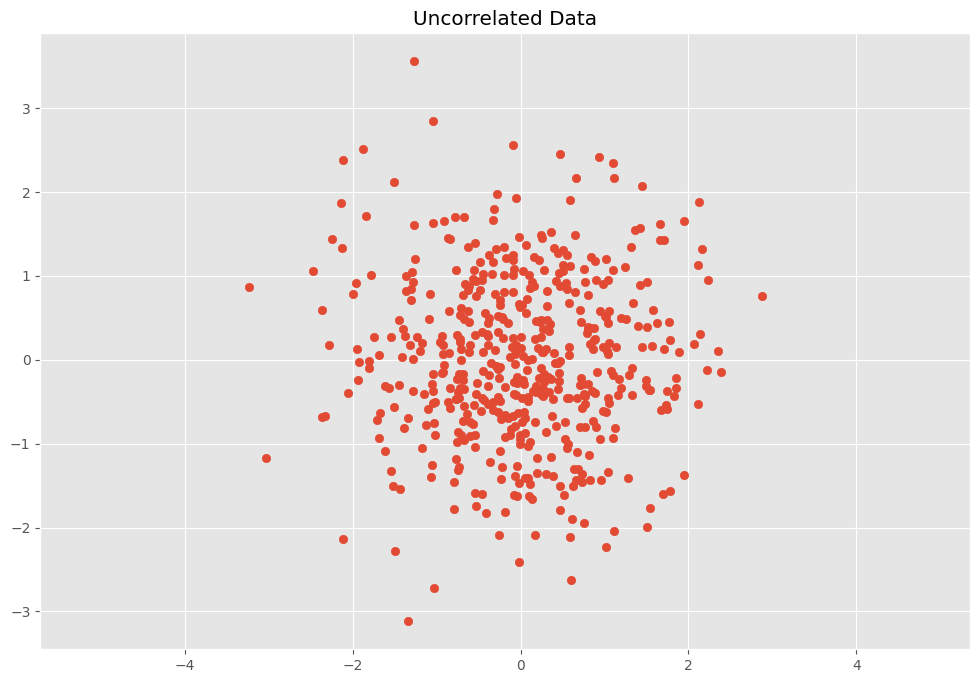

In [31]:
C = cov_mat(X_transf.T)

eVa, eVe = np.linalg.eig(C)

# Calculate transformation matrix from eigen decomposition
R, S = eVe, np.diag(np.sqrt(eVa))
# Здесь легко может быть ситуация, что R = -rot_mat, т.к. с т.з. eigendecomposition нет разницы между поворотом на 30 или на 210 (30+180)
S_inv = np.reciprocal(S, out=np.zeros_like(S), where=(S != 0))
R_inv = R.T

# X_transf = RS(X_Origin) => X_restored ~= X_origin = (S^-1)(R^-1)RS(X_Origin) = (S^-1)(R^-1)(X_transf)
X_restored = (S_inv @ R_inv @ X_transf.T).T

plt.scatter(X_restored[:, 0], X_restored[:, 1])
plt.title('Uncorrelated Data')
plt.axis('equal');

# Covariance matrix of the uncorrelated data
cov_mat(X_restored.T)

# Eigen and SVD

## Generate data

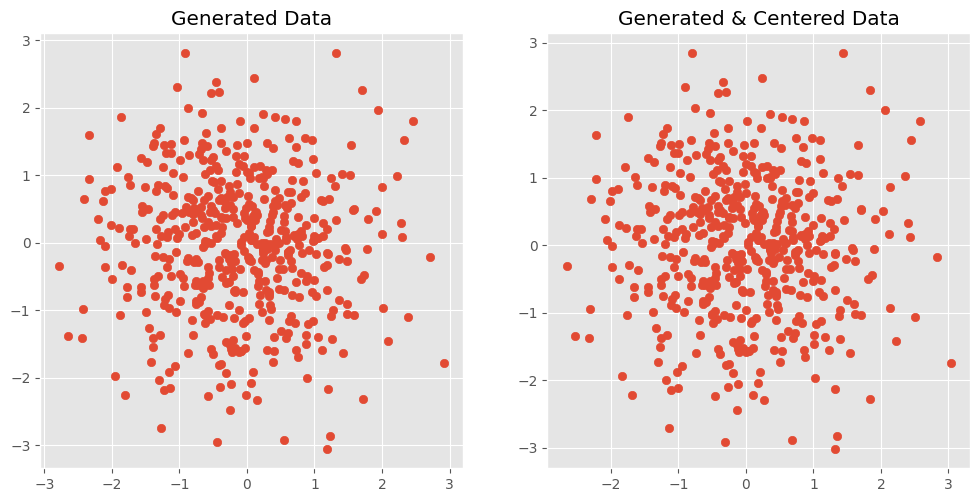

In [32]:
X_origin = RNG.normal(0, 1, (500, 2))

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.scatter(X_origin[:, 0], X_origin[:, 1])
ax1.set_title('Generated Data')
ax1.set_aspect('equal');# Center the matrix at the origin

X_origin = X_origin - np.mean(X_origin, 0)

ax2.scatter(X_origin[:, 0], X_origin[:, 1])
ax2.set_title('Generated & Centered Data')
ax2.set_aspect('equal');

## Scale + rotate

(array([[  2.21,  21.01],
        [ 21.01, 390.22]]),
 array([[  2.21,  21.01],
        [ 21.01, 390.22]]),
 array([[  2.21,  21.01],
        [ 21.01, 390.22]]),
 array([[  2.21,  21.01],
        [ 21.01, 390.22]]),
 array([[  2.21,  21.01],
        [ 21.01, 390.22]]),
 array([[  2.09,  20.85],
        [ 20.85, 398.91]]),
 array([[  2.09,  20.85],
        [ 20.85, 398.91]]))

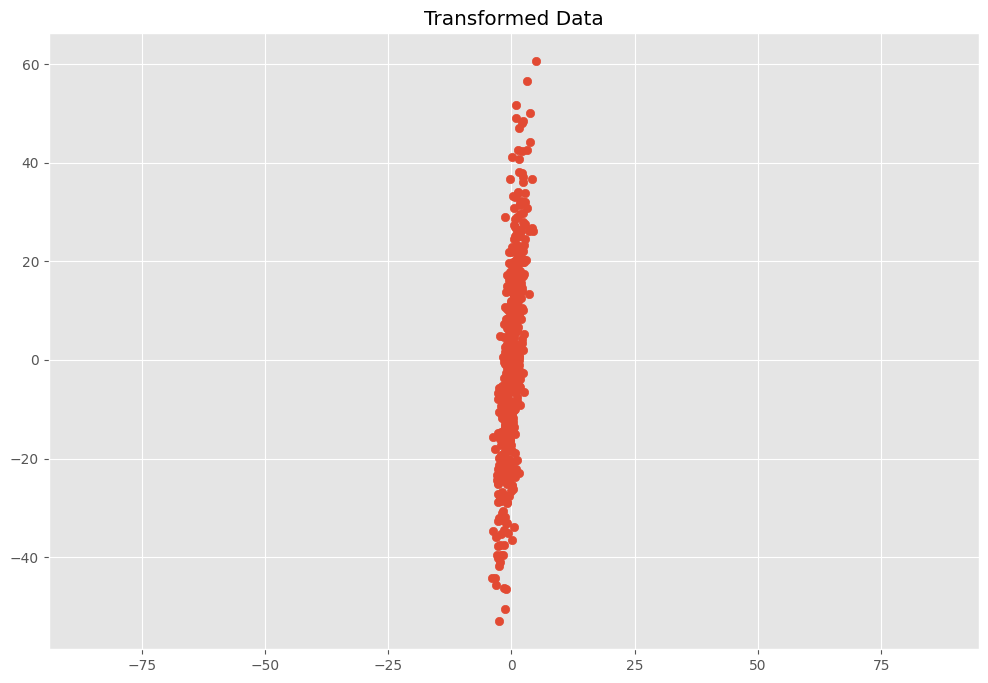

In [33]:
# Scaling matrix
sx, sy = 20, 1
scale_mat = np.array([[sx, 0], [0, sy]])

# Rotation matrix
theta = np.deg2rad(87)
c, s = np.cos(theta), np.sin(theta)
rot_mat = np.array([[c, -s], [s, c]])

# Transformation matrix
T = rot_mat @ scale_mat # сначала scale потом rot, T = RS

# Apply transformation matrix to X
# X_transf = (rot_mat @ scale_mat @ X_origin.T).T # X_transf = RS(X_Origin)
X_transf = (T @ X_origin.T).T # X_transf = RS(X_Origin)

plt.scatter(X_transf[:, 0], X_transf[:, 1])
plt.title('Transformed Data')
plt.axis('equal');

# Calculate covariance
c1 = cov_mat(X_transf.T)
c2 = (X_transf.T @ X_transf) / (len(X_transf) - 1)
R = rot_mat
S = scale_mat
c3 = ((R @ S @ X_origin.T) @ (R @ S @ X_origin.T).T) / (len(X_transf) - 1)
c4 = (R @ S @ X_origin.T @ (X_origin.T).T @ S.T @ R.T) / (len(X_transf) - 1)
c5 = (R @ S @ X_origin.T @ X_origin @ S.T @ R.T) / (len(X_transf) - 1)
# Meantime (X_origin.T @ X_origin) / (len(X_transf) - 1) is must converge to I, because X_origin is drawn from N(0, 1), as such ->
c6 = (R @ S @ S.T @ R.T) # => cov = T(T.T)
c7 = (R @ S @ S @ R.T) # => since scale_mat is symmetric
# c6 and c7 must converge to c1 when len(X_origin) -> inf. But given only several hunders of samples c6 and c7 are expected to differ from c1 to some extent
np.round(c1, 2), np.round(c2, 2), np.round(c3, 2), np.round(c4, 2), np.round(c5, 2), np.round(c6, 2), np.round(c7, 2)

## Eig decompose

In [34]:
c_hatch = (X_transf.T @ X_transf) / (len(X_transf) - 1)
eigvals, eigvecs = np.linalg.eig(c_hatch)
scale_mat_hatch = np.sqrt(np.diag(eigvals))
rot_mat_hatch = eigvecs

In [35]:
np.round(scale_mat_hatch, 2), np.round(scale_mat, 2)

(array([[ 1.04,  0.  ],
        [ 0.  , 19.78]]),
 array([[20,  0],
        [ 0,  1]]))

In [36]:
np.round(rot_mat_hatch, 2), np.round(rot_mat, 2)

(array([[-1.  , -0.05],
        [ 0.05, -1.  ]]),
 array([[ 0.05, -1.  ],
        [ 1.  ,  0.05]]))

## SVD decompose

In [37]:
U, S, V = np.linalg.svd(X_transf)
# scale_mat_hatch = np.sqrt(np.diag(S ** 2) / (len(X_transf) - 1))
scale_mat_hatch = np.diag(S) / np.sqrt(len(X_transf) - 1) # corresponds to upper commented line
rot_mat_hatch = V.T

In [38]:
np.round(scale_mat_hatch, 2), np.round(scale_mat, 2)

(array([[19.78,  0.  ],
        [ 0.  ,  1.04]]),
 array([[20,  0],
        [ 0,  1]]))

In [39]:
np.round(rot_mat_hatch, 2), np.round(rot_mat, 2)

(array([[-0.05,  1.  ],
        [-1.  , -0.05]]),
 array([[ 0.05, -1.  ],
        [ 1.  ,  0.05]]))

# What is a line?

## y=kx+b

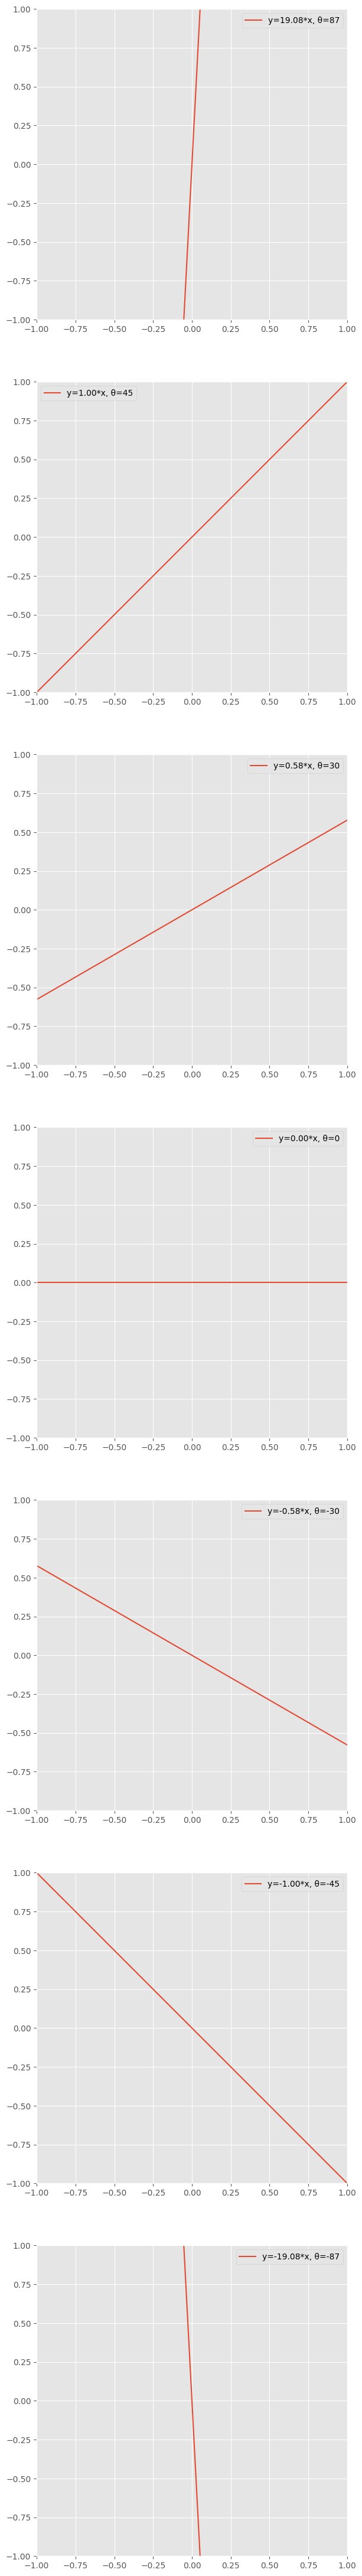

In [40]:
thetas = [87, 45, 30, 0, -30, -45, -87]
xs = np.linspace(-1, +1, 100)
fig, axes = plt.subplots(len(thetas))
fig.set_figwidth(8)
fig.set_figheight(8 * len(axes))
axes = axes.ravel()
assert len(axes) >= len(thetas), (len(thetas), len(axes))

for theta, ax in zip(thetas, axes):
    k = np.tan(np.deg2rad(theta))
    ys = k * xs
    ax.plot(xs, ys, label=f'y={k:.2f}*x, θ={theta}')
    ax.set_xlim(-1, +1)
    ax.set_ylim(-1, +1)
    ax.set_aspect('equal')
    ax.grid(True)
    ax.legend()

## Direct construction of cov_mat

Есть x1 и x2, которые нормально распределены N(0, 1). Т.е. sigma_x1 == sigma_x2 == 1 => std(x1) == std(x2) == 1. Далее говорим, что x1 и x2 совершенно коррелированы, и образуют прямую под углом theta

In [41]:
# Pure uncorrelated x1 and x2 with std==1
pristine_ys = RNG.multivariate_normal(mean=np.zeros(2), cov=np.eye(2), size=1000)

In [113]:
# 1 / np.sqrt(2/4)

np.float64(1.414213562373095)

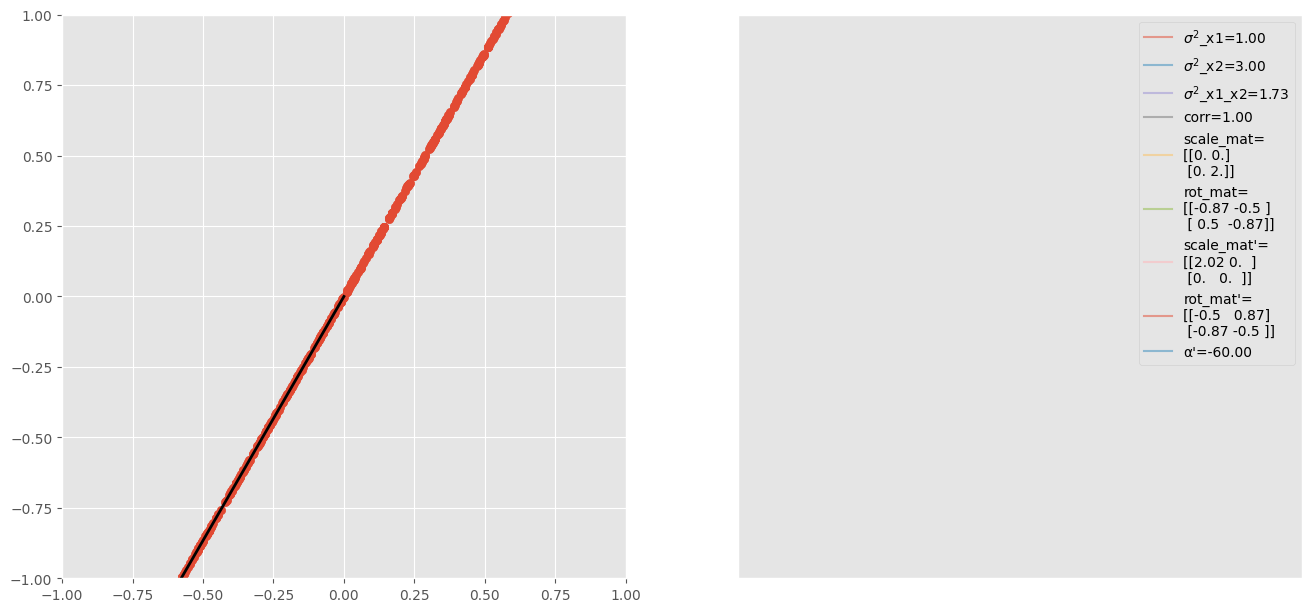

In [108]:
theta = np.deg2rad(60)
sigma_x1 = 1 
sigma_x2 = np.tan(theta) ** 2
corr = 1
# коэфф корреляции = коэфф. ковариации / стд.оклоннения. Поэтому имея коэфф корреляции, коэфф ковариации равен = коэфф.корреляции * стд.отклонения
sigma_x1_x2 = corr * np.sqrt(sigma_x1) * np.sqrt(sigma_x2) * np.sign(theta)

Σ = np.array([
    [sigma_x1,    sigma_x1_x2],
    [sigma_x1_x2, sigma_x2],
])

ys = RNG.multivariate_normal(
    mean=np.zeros(Σ.shape[0]),
    cov=Σ,
    size=len(pristine_ys))

# Матрицы масштаба и поворота непосредственно из матрицы ковариации
eigvals, eigvecs = np.linalg.eig(Σ)
scale_mat = np.sqrt(np.diag(eigvals))
rot_mat = eigvecs

# Матрицы масштаба и поворота на основе сгенерённых данных!
U, S, V = np.linalg.svd(ys)
scale_mat_hatch = np.diag(S) / (np.sqrt(len(ys) - 1))
rot_mat_hatch = V.T

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(16)
fig.set_figheight(8)

# Дисперсия - суть площадь квадратов! Разкомментить, чтобы увидеть каких
# min_x1, max_x1 = np.min(ys[:,0]), np.max(ys[:,0])
# ax1.fill([min_x1, min_x1, max_x1, max_x1], [min_x1, max_x1, max_x1, min_x1], hatch='*', fill=False, color='C0', alpha=0.5, label=f'σ_x1={sigma_x1:g}')
# min_x2, max_x2 = np.min(ys[:,1]), np.max(ys[:,1])
# ax1.fill([min_x2, min_x2, max_x2, max_x2], [min_x2, max_x2, max_x2, min_x2], hatch='o', fill=False, color='C1', alpha=0.5, label=f'σ_x2={sigma_x2:g}')
# min_x2, max_x2 = np.min(ys[:,1]), np.max(ys[:,1])
# ax1.fill([min_x1, min_x1, max_x1, max_x1], [min_x2, max_x2, max_x2, min_x2], hatch='+', fill=False, color='C2', alpha=0.5, label=f'σ_x1_x2={sigma_x1_x2:g}\ncorr={corr:.2f}')

ax1.scatter(ys[:,0], ys[:,1], color='C0')
ax1.plot([0, V[0,0] * 3], [0, V[0,1] * 3], color='k', lw=2)

ax1.set_xlim(-sigma_x1, sigma_x1)
ax1.set_ylim(-sigma_x1, sigma_x1)
ax1.set_aspect('equal')
ax1.grid(True)

ax2.plot([], [], alpha=0.5, label=f'$σ^2$_x1={Σ[0,0]:.2f}')
ax2.plot([], [], alpha=0.5, label=f'$σ^2$_x2={Σ[1,1]:.2f}')
ax2.plot([], [], alpha=0.5, label=f'$σ^2$_x1_x2={Σ[0,1]:.2f}')
ax2.plot([], [], alpha=0.5, label=f'corr={corr:.2f}')
ax2.plot([], [], alpha=0.5, label=f'scale_mat=\n{np.round(scale_mat, 2)}')
ax2.plot([], [], alpha=0.5, label=f'rot_mat=\n{np.round(rot_mat, 2)}')
ax2.plot([], [], alpha=0.5, label=f'scale_mat\'=\n{np.round(scale_mat_hatch, 2)}')
ax2.plot([], [], alpha=0.5, label=f'rot_mat\'=\n{np.round(rot_mat_hatch, 2)}')
ax2.plot([], [], alpha=0.5, label=f'α\'={np.rad2deg(np.arctan(rot_mat_hatch[0,1]/rot_mat_hatch[0,0])):.2f}')
ax2.grid(False)
ax2.set_aspect('equal')
ax2.set_xticks([])
ax2.set_yticks([])
ax2.legend();

## Line based on restored scale_mats and rot_mats

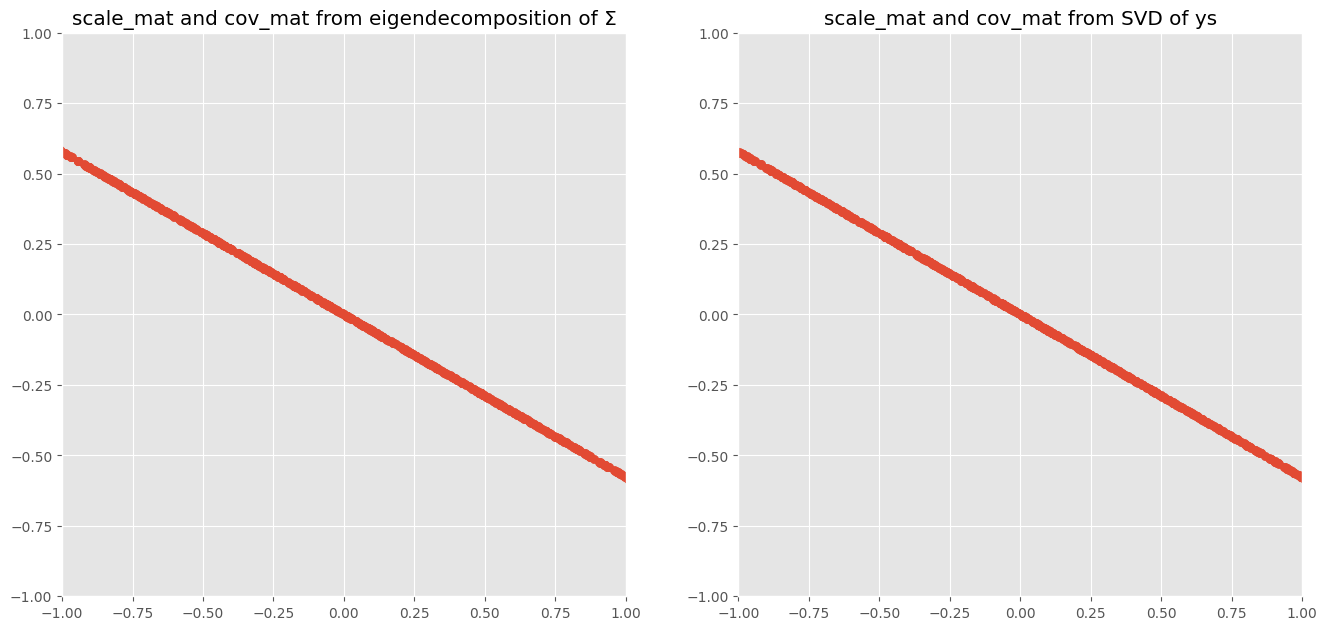

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(16)
fig.set_figheight(8)

ys = (rot_mat @ scale_mat @ pristine_ys.T).T
ax1.scatter(ys[:,0], ys[:,1])
ax1.set_xlim(-1, +1)
ax1.set_ylim(-1, +1)
ax1.set_aspect('equal')
ax1.set_title('scale_mat and cov_mat from eigendecomposition of Σ')

ys = (rot_mat_hatch @ scale_mat_hatch @ pristine_ys.T).T
ax2.scatter(ys[:,0], ys[:,1])
ax2.set_xlim(-1, +1)
ax2.set_ylim(-1, +1)
ax2.set_aspect('equal')
ax2.set_title('scale_mat and cov_mat from SVD of ys');

## Line at 87 deg: variance of x1=0, and rotate CW 3

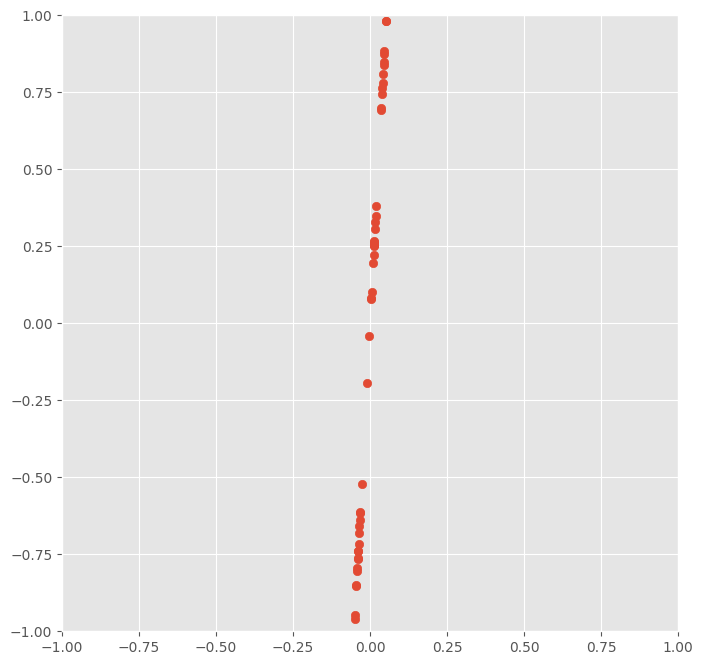

In [44]:
theta1 = np.deg2rad(-3)
scale_mat1 = np.diag([0, 19])
rot_mat1 = np.array([[np.cos(theta1), -np.sin(theta1)], [np.sin(theta1), np.cos(theta1)]]) 

ys = (rot_mat1 @ scale_mat1 @ pristine_ys.T).T

fig, ax1 = plt.subplots(1, 1)
fig.set_figwidth(8)
fig.set_figheight(8)
ax1.scatter(ys[:,0], ys[:,1])
ax1.set_xlim(-1, +1)
ax1.set_ylim(-1, +1)
ax1.set_aspect('equal')

## Line at 87 deg: variance of x2=0, and rotate CCW 87

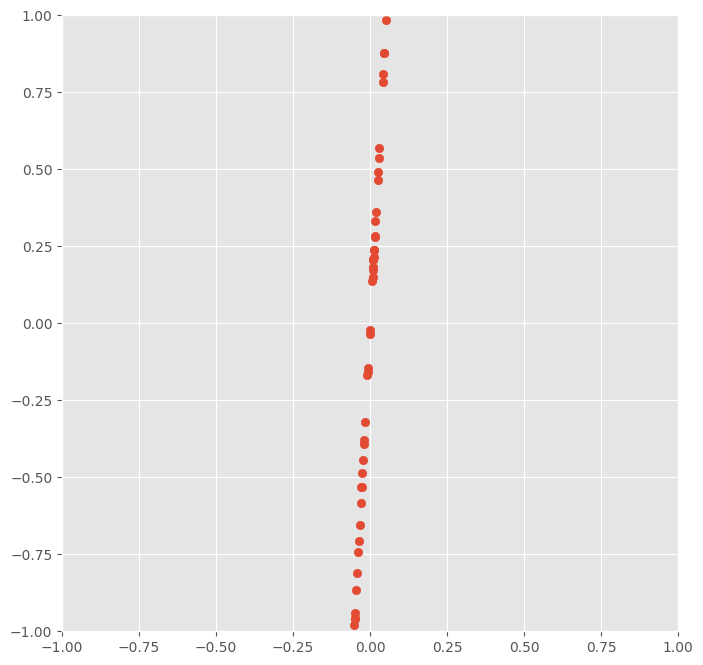

In [45]:
theta1 = np.deg2rad(87)
scale_mat1 = np.diag([19, 0])
rot_mat1 = np.array([[np.cos(theta1), -np.sin(theta1)], [np.sin(theta1), np.cos(theta1)]]) 

ys = (rot_mat1 @ scale_mat1 @ pristine_ys.T).T

fig, ax1 = plt.subplots(1, 1)
fig.set_figwidth(8)
fig.set_figheight(8)
ax1.scatter(ys[:,0], ys[:,1])
ax1.set_xlim(-1, +1)
ax1.set_ylim(-1, +1)
ax1.set_aspect('equal')

## Concludes

1) прямая линия получается, когда значение одной из переменной схлопывается в 0 (дисперсия тоже 0 становится равной), с последующим поворотом. Т.е. из облака мы получаем линиую, и потом её вертим.
2) благодаря повороту дисперсия схлопнутой переменной восстанавливается из 0, кроме случаев, когда theta=0,90,270, 360
3) прямую можно получить схлопнув любую из двух переменных. Просто тогда поворот нужен будет либо CW, либо CCW
4) коэффициент корреляции будет равен 1
5) но кросс-вариация не будет 1, т.к. кросс-вариация собирается как произведение дисперсий переменных. Т.е. кросс-вариация может быть значительное. Ну это и про вариацию (дисперсию) отдельное переменной тоже
6) вполне себе прямые линии получаются и из восстановленных с помощью SVD матриц ковариаций

# Cholesky and T

In [88]:
X_origin = RNG.normal(0, 1, (500, 2))
X_origin = X_origin - np.mean(X_origin, 0)

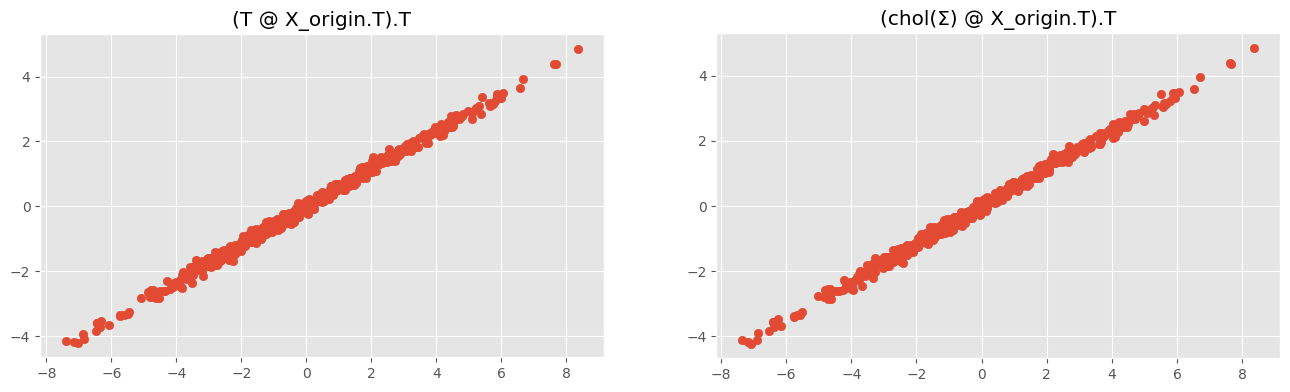

In [89]:
sx, sy = 3.4, 0.1
# scale_mat = np.eye(2)
scale_mat = np.array([[sx, 0], [0, sy]])

theta = np.deg2rad(30)
c, s = np.cos(theta), np.sin(theta)
# rot_mat = np.eye(2)
rot_mat = np.array([[c, -s], [s, c]])

T = rot_mat @ scale_mat
Σ = rot_mat @ scale_mat @ scale_mat @ rot_mat.T
chol = np.linalg.cholesky(Σ)

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(16)
fig.set_figheight(8)

X_transf1 = (T @ X_origin.T).T 
X_transf2 = (chol @ X_origin.T).T 

ax1.scatter(X_transf1[:, 0], X_transf1[:, 1])
ax1.set_title('(T @ X_origin.T).T')
ax1.set_aspect('equal');

ax2.scatter(X_transf2[:, 0], X_transf2[:, 1])
ax2.set_title('(chol(Σ) @ X_origin.T).T')
ax2.set_aspect('equal');

In [90]:
Σ, T @ T.T

(array([[8.6725    , 5.00129671],
        [5.00129671, 2.8975    ]]),
 array([[8.6725    , 5.00129671],
        [5.00129671, 2.8975    ]]))

In [92]:
assert np.all(np.isclose(T @ T.T, Σ))

Видно, что, действительно, **T @ T.T == Σ**

In [91]:
Σ, chol @ chol.T

(array([[8.6725    , 5.00129671],
        [5.00129671, 2.8975    ]]),
 array([[8.6725    , 5.00129671],
        [5.00129671, 2.8975    ]]))

In [93]:
assert np.all(np.isclose(chol @ chol.T, Σ))

Видно, что, действительно, **chol @ chol.T == Σ**

In [85]:
T, chol

(array([[ 2.94448637, -0.05      ],
        [ 1.7       ,  0.08660254]]),
 array([[2.94491086, 0.        ],
        [1.69828458, 0.11545341]]))

In [94]:
np.all(np.isclose(T, chol))

np.False_

1) Видно, что T != chol
2) Но при этом что прикладывание T к X_origin, что прикладывание chol к X_origin, даёт одинаковые результаты (пусть и не 100% идентичность, но визуально да)!!!
3) Получается, что chol может быть а) заменой eigendecomposition(Σ) или б) заменой SVD(X_transf) в части получения R@S

# Eigen and cov

Ковариационная матрица может быть представлена $C=RSS^T$$R^{-1}$, где R - матрица поворота, S - матрица масштабирования.  
Т.к. S - симетричная, то $S^T=S$.  
Т.к. R - ортогональная, то $R^{-1}=R^T$.  
Таким образом $C=RSS$$R^{T}$.

При этом C может быть eigen-декомпозирована на $C=EVE^{T}$, где E - eigenvectors, V - диагональная матрица eigenvalues.

Таким образом R есть E, и наоборот. А $V$ есть коэффициенты масштабирования, т.е. $SS=S^2$.

Получается, что матрица ковариации может рассматриваться в следующем ключе:  
- имеется облако нормально распределённое, которое есть сфера (идеальная). По-факту имеем identity матрицу $I$
- у идеальной сферы бесконечное кол-во собственных векторов, т.к. какой вектор $v$ не возьми $Iv=v$
- выбирается какой-то вектор в этом облаке
- выполняется поворот, так чтобы вектор $v$ совпал с дефолтной осью (например, $X$)
- выполняется масштабирование по разным осям 2х раза
- затем всё обратно вертается

Таким образом облако можно деформировать и превратить, хоть в линию, хоть в эллипс.

**Вопрос**: каким получается стандартное отклонение, после поворота?  
**Ответ**: это будет окаймление деформированного эллипса. Формула на картинке ниже и в реализации.

![](img/eigen_cov_mat_1.jpg)
![](img/eigen_cov_mat_2.jpg)

Формируем чистый круг - представитель 2-х мерного нормально распределения

(np.float64(-1.1), np.float64(1.1), np.float64(-1.1), np.float64(1.1))

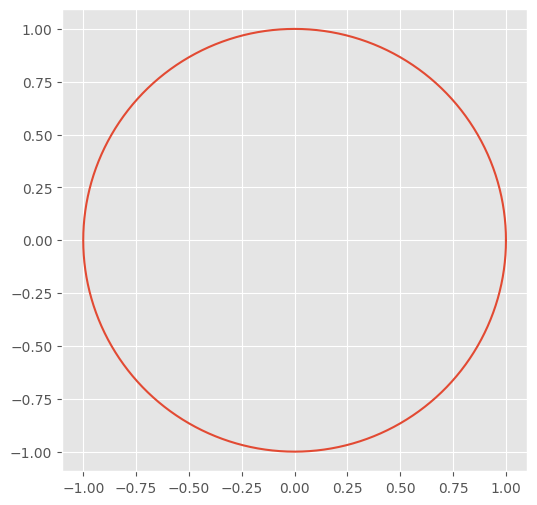

In [770]:
thetas = np.deg2rad(np.linspace(0, 360, 361))
points = np.vstack([np.cos(thetas), np.sin(thetas)]).T

plt.figure(figsize=(6,6))
plt.plot(points[:,0], points[:,1])
plt.axis('equal')

Теперь деформируем этот круг и покажем стандартные отклонения.  
Деформируем за счёт поворота и масштабирования. Повороты (rot_mat) будут являться eigenvectors, масштабирование (scale_mat) - $\sqrt{eigenvalues}$.  
**Важно!** Без масштабирования поворот теряет всякий смысл, т.к. круг (сфера) как её не вращай, всегда остается одинаковой. Т.е. $C=RIIR^T=I$

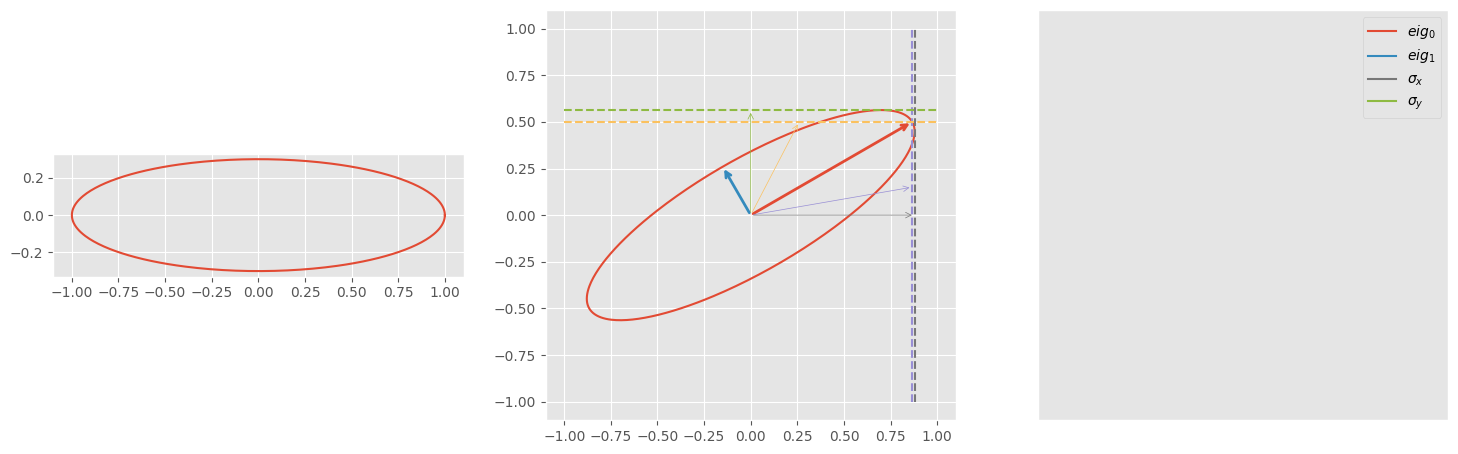

In [217]:
sx, sy = 1, 0.3
scale_mat = np.array([[sx, 0], [0, sy]])
theta = 30
c = np.cos(np.deg2rad(theta))
s = np.sin(np.deg2rad(theta))
rot_mat = np.array([[c, -s],[s, c]])
points_scaled = (scale_mat @ points.T).T
points_scaled_rotated = (rot_mat @ scale_mat @ points.T).T

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figwidth(18)
fig.set_figheight(6)

ax1.plot(points_scaled[:,0], points_scaled[:,1])
ax1.set_aspect('equal');

ax2.plot(points_scaled_rotated[:,0], points_scaled_rotated[:,1])
ax2.annotate('', xytext=(0, 0), xy=(c * sx, s * sx), arrowprops=dict(arrowstyle="->", color='C0', lw=2), annotation_clip=False)
ax2.annotate('', xytext=(0, 0), xy=(-s * sy, c * sy), arrowprops=dict(arrowstyle="->", color='C1', lw=2), annotation_clip=False)

ax2.annotate('', xytext=(0, 0), xy=(c * sx, s * sy), arrowprops=dict(arrowstyle="->", color='C2'), annotation_clip=False)
ax2.vlines(c * sx, -1, 1, color='C2', linestyles='dashed')
std_x = np.linalg.norm([c * sx, s * sy])
ax2.annotate('', xytext=(0, 0), xy=(std_x, 0), arrowprops=dict(arrowstyle="->", color='C3'), annotation_clip=False)
ax2.vlines(std_x, -1, 1, color='C3', linestyles='dashed')

ax2.annotate('', xytext=(0, 0), xy=(c * sy, s * sx), arrowprops=dict(arrowstyle="->", color='C4'), annotation_clip=False)
ax2.hlines(s * sx, -1, 1, color='C4', linestyles='dashed')
std_y = np.linalg.norm([s * sx, c * sy])
ax2.annotate('', xytext=(0, 0), xy=(0, std_y), arrowprops=dict(arrowstyle="->", color='C5'), annotation_clip=False)
ax2.hlines(std_y, -1, 1, color='C5', linestyles='dashed')

ax2.set_aspect('equal');

ax3.plot([],[], color='C0', label='$eig_0$')
ax3.plot([],[], color='C1', label='$eig_1$')
ax3.plot([],[], color='C3', label='$σ_x$')
ax3.plot([],[], color='C5', label='$σ_y$')
ax3.grid(False)
ax3.set_xticks([])
ax3.set_yticks([])
ax3.set_aspect('equal')
ax3.legend();

# Crafting of cov with desired features

**Задача**

Создать многомерное нормальное распределение так, чтобы:  
- переменные были коррелированы
- степень коррелированности можно было бы задавать
- дисперсию (стд. отклонение) переменных можно было бы задавть

Почему именно так? Потому что тогда можно получить Probability Density Function (PDF) и:

1) использовать её для Maximum Likelihood (ML).
2) использовать в Gaussian Process.

## Appr. 1. Sequential rotation (rejected)

Идея была следующая. У нас есть целевой eigenvector (единичный вектор), например, $(\sqrt{3},\sqrt{3},\sqrt{3})$. Значит, нужно родить матрицу поворота, которая бы дефолтный вектор (1,0,0) повернула бы до $(\sqrt{3},\sqrt{3},\sqrt{3})$. Нужно два поворота: сначала вертает вокруг оси Y на 45 градусов, потом вертаем вокруг оси Z тоже на 45 градусов. 

Но этот подход оказался провальным:
1) после первого поворота плоскости XZ вокруг оси Y второй поворот нужно делать не вокруг оси Y, а вокруг новой оси. Т.е. вроде как нужно сделать переход в новую систему координат, там ворочать, потом обратно
2) второй поворот нужно делать не на 45 градусов, а где-то на 35 градусов, т.к. куб имеют плоскостную диагональ длиной $\sqrt{2}$, катет длиной 1, и следовательно диагональ от (0,0,0) до (1,1,1) будет равна $\sqrt{3}$



Видно, что угол где-то 35 градусов.

![](img/craft_cov_mat_1.jpg)


Демо двух последовательных поворотов на 45 градусов. Видно, что линия не попала в (1,1,1)

![](img/craft_cov_mat_2.jpg)



In [300]:
# Choose a vector to be a major eigenvector, rotate vector to origin, squish all dimensions except the first one, rotate vector back where it was
theta = np.deg2rad(45)
cos_theta = np.cos(theta)
sin_theta = np.sin(theta)

theta2 = np.aarcsin(1/(np.sqrt(2+1)))
cos_theta2 = np.cos(theta2)
sin_theta2 = np.sin(theta2)
                   
rot_mat1 = np.eye(3)
# rot_mat1[0,0] = cos_theta
# rot_mat1[0,1] = -sin_theta
# rot_mat1[1,0] = sin_theta
# rot_mat1[1,1] = cos_theta

# CCW поворот плоскости XZ вокруг оси Y (правосторонний базис) 
rot_mat2 = np.eye(3)
rot_mat2[0,0] = cos_theta
rot_mat2[0,2] = sin_theta
rot_mat2[2,0] = -sin_theta
rot_mat2[2,2] = cos_theta

rot_mat3 = np.eye(3)
rot_mat3[0,0] = cos_theta2
rot_mat3[0,1] = -sin_theta2
rot_mat3[1,0] = sin_theta2
rot_mat3[1,1] = cos_theta2

# CW поворот плоскости YZ вокруг оси X (правосторонний базис)  
rot_mat4 = np.eye(3)
rot_mat4[1,1] = cos_theta2
rot_mat4[1,2] = -sin_theta2
rot_mat4[2,1] = sin_theta2
rot_mat4[2,2] = cos_theta2

rot_mat = rot_mat3 @ rot_mat2 @ rot_mat1

# scale_mat = np.diag(np.full(3, np.sqrt(3)))
scale_mat = np.diag([np.sqrt(3)] + [0] * 2)

cov_mat = rot_mat @ scale_mat @ scale_mat @ rot_mat.T


## Appr. 2. Craft new basis

Идея тогда следующая - воспользоваться операцией "change of basis". Но для этого нужен новый базис. А у нас есть один желанный eigenvector, например, $(\sqrt{3},\sqrt{3},\sqrt{3})$. Где взять оставшиеся N-1 векторов?

Пробуем для 3-х мерного случая.

How to compute basis (orthonormal vectors) given single vector. I.e. how to augument given signle vector in order to get a basis:

- https://backend.orbit.dtu.dk/ws/portalfiles/portal/126824972/onb_frisvad_jgt2012_v2.pdf
- https://graphics.pixar.com/library/OrthonormalB/paper.pdf
- https://blog.selfshadow.com/2011/10/17/perp-vectors/

<code>
void naive ( const Vec3f & n , Vec3f & b1 , Vec3f & b2 ) {
    // If n is near the x-axis , use the y- axis . Otherwise use the x- axis .
    if(n.x > 0.9 f ) b1 = Vec3f (0.0 f , 1.0 f , 0.0 f );
    else b1 = Vec3f (1.0 f , 0.0 f , 0.0 f );
    b1 -= n* dot (b1 , n ); // Make b1 orthogonal to n
    // kms@ n * dot (b1 , n ) = projection of n on b1 (and vice versa). 
    // kms@ Hence, subtracting this projection we get a vector which has 0 value of dot product i.e. is orthogonal
    // kms@ The same trick is used in Gram-Smidt process.
    b1 *= rsqrt ( dot (b1 , b1 )); // Normalize b1
    b2 = cross (n , b1 ); // Construct b2 using a cross product
}

void hughes_moeller ( const Vec3f & n , Vec3f & b1 , Vec3f & b2 ) {
    // Choose a vector orthogonal to n as the direction of b2.
    if( fabs (n.x ) > fabs (n. z )) b2 = Vec3f (-n.y , n .x , 0.0 f );
    else b2 = Vec3f (0.0 f , -n.z , n.y );
    b2 *= rsqrt ( dot (b2 , b2 )); // Normalize b2
    b1 = cross (b2 , n ); // Construct b1 using a cross product
}

void frisvad ( const Vec3f & n , Vec3f & b1 , Vec3f & b2 ) {
    if(n.z < -0.9999999f) // Handle the singularity {
        b1 = Vec3f ( 0.0f , -1.0f , 0.0f );
        b2 = Vec3f ( -1.0f , 0.0f , 0.0f );
        return ;
    }
    const float a = 1.0f /(1.0f + n.z );
    const float b = -n.x * n.y * a ;
    b1 = Vec3f (1.0 f - n.x * n. x * a , b , -n.x );
    b2 = Vec3f (b , 1.0 f - n.y * n.y * a , -n.y );
}
</code>

In [333]:
def get_3d_basis_frisvad(v):
    # v is assumed be be a unit vector
    if v[2] < -0.9999999:
        b1 = np.array([0, -1, 0])
        b2 = np.array([-1, 0, 0])
    else:
        a = 1 / (1 + v[2])
        b = -v[0] * v[1] * a
        b1 = np.array([1 - v[0] * v[0] * a, b, -v[0]])
        b2 = np.array([b, 1 - v[1] * v[1] * a,  -v[1]])
    
    return np.vstack([v, b1, b2]).T

In [339]:
v = np.array([1, 1, 1])
v = v / np.linalg.norm(v)
basis = get_3d_basis_frisvad(v)
np.round([basis[0] @ basis[1], basis[0] @ basis[2], basis[1] @ basis[2]], 2)

array([0., 0., 0.])

In [530]:
scale_mat = np.eye(3)
scale_mat[0,0] = np.sqrt(3)
scale_mat[1,1] = 0.01
scale_mat[2,2] = 1
rot_mat = basis
cov_mat = rot_mat @ scale_mat @ scale_mat @ rot_mat.T
cov_mat, cov_mat[0, 1] / np.sqrt(cov_mat[0,0]) / np.sqrt(cov_mat[1,1]), cov_mat[0, 2] / np.sqrt(cov_mat[0,0]) / np.sqrt(cov_mat[2,2])

(array([[1.0447204 , 0.83331667, 1.12196293],
        [0.83331667, 1.62201293, 0.5446704 ],
        [1.12196293, 0.5446704 , 1.33336667]]),
 np.float64(0.6401516570845601),
 np.float64(0.9506128376609976))

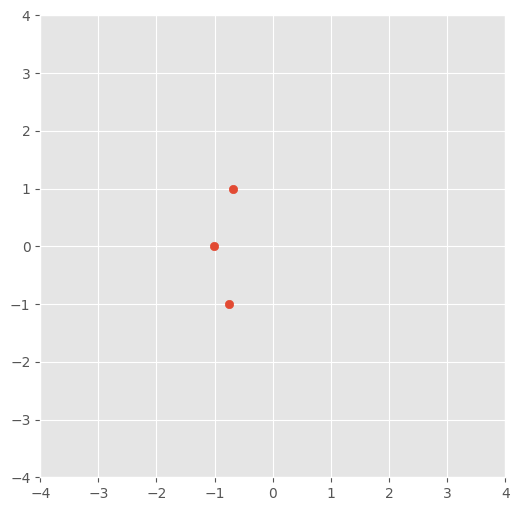

In [558]:
points_count = len(cov_mat)
points = RNG.multivariate_normal(
    mean=np.zeros(points_count), 
    cov=cov_mat)

fig, ax1 = plt.subplots(1, 1)
fig.set_figwidth(6)
fig.set_figheight(6)
ax1.scatter(points, np.linspace(-1, 1, points_count))
ax1.set_xlim(-4, 4)
ax1.set_ylim(-4, 4)
ax1.grid(True)

А как теперь для N-мерного пространства? 

Для этого может подойти Gram-Smidt process или QR-декомпозиция (которая есть матричное представление Gram-Smidth процесса). Мы просто далем наш eigenvector первым базисным вектором, добавляем к нему оставшиеся unit-вектора, и далее QR уже сделает из этого ортнонормированный базис.

Тут есть инфа:
- https://www.youtube.com/watch?v=zHbfZWZJTGc
- https://www.youtube.com/watch?v=FAnNBw7d0vg

По факту мы делаем итеративно то, что было упомянуто в naive функции - последовательно формирует ортогональные вектора, вычитая уже имеющиеся.

In [775]:
# Simple 3d case
start_basis = np.array([
    np.full(3, 1),
    np.array([0, 1, 0]),
    np.array([0, 0, 1]),
]).T
Q, R = np.linalg.qr(start_basis)
start_basis, np.round(Q, 2)

(array([[1, 0, 0],
        [1, 1, 0],
        [1, 0, 1]]),
 array([[-0.58,  0.41, -0.71],
        [-0.58, -0.82, -0.  ],
        [-0.58,  0.41,  0.71]]))

In [777]:
# if we put duplicates vector - QR can handle this as well
start_basis = np.array([
    np.array([0, 1, 0]),
    np.array([0, 1, 0]),
    np.array([0, 0, 1]),
]).T
Q, R = np.linalg.qr(start_basis)
start_basis, np.round(Q, 2)

(array([[0, 0, 0],
        [1, 1, 0],
        [0, 0, 1]]),
 array([[ 0., -1.,  0.],
        [-1.,  0.,  0.],
        [-0.,  0.,  1.]]))

Теперь для произвольного кол-ва точек

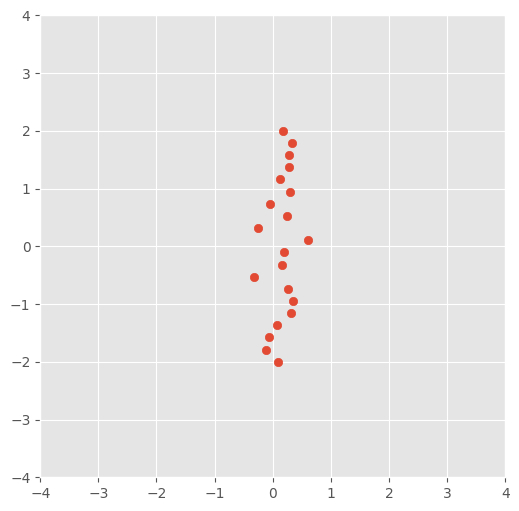

In [769]:
points_count = 20
fixed_vector = np.full(points_count, 1) #  vector (1,1,1,...)
start_basis = np.eye(points_count)
start_basis[:,0] = fixed_vector
Q, R = np.linalg.qr(start_basis)
rot_mat = Q

scale_mat = np.diag(np.full(points_count, 0.05))
scale_mat[0,0] = 1
cov_mat = rot_mat @ scale_mat @ scale_mat @ rot_mat.T

# How to control variance on main diagonal of cov_mat?
# Recall that variance=std^2 and cov_mat contains variances on diagonal
# std_x1 = linalg.norm([sin * scale_mat[0, 0], cos * scale_mat[1, 1], ...])
# in order to get e.g. std_x1 = 1 mentioned linalg.norm(...) should equal to sqrt(1)
# to ensure target_std we can:
# 0) current_std_x1 = sqrt(cov_mat[0,0])
# 1) construct equation linalg.norm(...) = current_std_x1
# 2) devide both side by current_std_x1
# 3) move current_std_x1 under square root linalg.norm(...) = sqrt((cos*scale_mat[0,0])^2 + (sin*scale_mat[1,1])^2 ...)
# 4) as such each scale_mat[i,i] should get mult factor = 1 / current_std_x1

target_std = 1
scale_mat *= (target_std / np.sqrt(cov_mat[0,0]))
cov_mat = rot_mat @ scale_mat @ scale_mat @ rot_mat.T

points = RNG.multivariate_normal(
    mean=np.zeros(points_count), 
    cov=cov_mat)

fig, ax1 = plt.subplots(1, 1)
fig.set_figwidth(6)
fig.set_figheight(6)
ax1.scatter(points, np.linspace(-2, 2, points_count))
ax1.set_xlim(-4, 4)
ax1.set_ylim(-4, 4)
ax1.grid(True)